# Notebook 02: EDA and Outcome Analysis

This notebook explores the cleaned UCI diabetes readmission dataset created in Notebook 01.

The goal is to understand:

- 30-day readmission prevalence
- population structure
- missingness patterns
- feature distributions
- observed readmission-rate differences across key variables

All findings in this notebook are descriptive. This notebook does not make causal claims.

This notebook remains encounter-level. Because some patients appear in multiple encounters, later modeling notebooks must use patient-aware train/test splitting with `patient_nbr` as the grouping variable. EDA tables here are descriptive and do not represent model validation.

A simple random row-level split could place encounters from the same patient in both training and test sets, causing train/test contamination and inflated model performance.

Recommended later splitting approaches include `GroupShuffleSplit`, `GroupKFold`, or `StratifiedGroupKFold`.

## 1. Imports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

## 2. Project Paths

In [2]:
# Allows the notebook to run whether opened from the project root or the notebooks folder.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
OUTPUTS = PROJECT_ROOT / "outputs"
FIGURES = OUTPUTS / "figures"
MODEL_RESULTS = OUTPUTS / "model_results"

for path in [DATA_RAW, DATA_PROCESSED, OUTPUTS, FIGURES, MODEL_RESULTS]:
    path.mkdir(parents=True, exist_ok=True)

print("Project root detected successfully.")
print("Project folder:", PROJECT_ROOT.name)

Project root detected successfully.
Project folder: 03_risk_stratification_intervention_prioritization


## 3. Load and Validate Data

In [3]:
cleaned_path = DATA_PROCESSED / "diabetes_readmission_cleaned.csv"

assert cleaned_path.exists(), f"Missing cleaned dataset: {cleaned_path}"

df = pd.read_csv(cleaned_path, low_memory=False)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (101766, 51)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,readmitted_30d
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO,0
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30,0
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO,0
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO,0
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO,0


In [4]:
# Notebook 01 should have created this binary target.
assert "readmitted_30d" in df.columns, "Missing target column: readmitted_30d"

# Target should only contain 0 and 1.
assert set(df["readmitted_30d"].dropna().unique()) <= {0, 1}, "Target is not binary."

baseline_readmission_rate = df["readmitted_30d"].mean()

print(f"Baseline 30-day readmission rate: {baseline_readmission_rate:.2%}")

target_summary = (
    df["readmitted_30d"]
    .value_counts()
    .rename_axis("readmitted_30d")
    .reset_index(name="count")
)

target_summary["pct"] = target_summary["count"] / len(df)

display(target_summary)

Baseline 30-day readmission rate: 11.16%


,readmitted_30d,count,pct
0,0,90409,0.888401
1,1,11357,0.111599


### Interpretation

The dataset loaded successfully from the cleaned output of Notebook 01.

The `readmitted_30d` target is binary:

- `1`: readmitted within 30 days
- `0`: not readmitted within 30 days

The baseline 30-day readmission rate is the reference point for later model and outreach-threshold evaluation.

## 4. Outcome Overview

In [5]:
readmitted_distribution = (
    df["readmitted"]
    .value_counts(dropna=False)
    .rename_axis("readmitted")
    .reset_index(name="count")
)

readmitted_distribution["pct"] = readmitted_distribution["count"] / len(df)

display(readmitted_distribution)

,readmitted,count,pct
0,NO,54864,0.539119
1,>30,35545,0.349282
2,<30,11357,0.111599


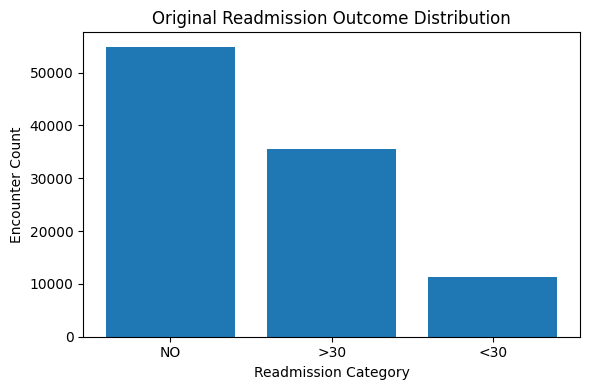

In [6]:
plt.figure(figsize=(6, 4))
plt.bar(
    readmitted_distribution["readmitted"].astype(str),
    readmitted_distribution["count"]
)
plt.title("Original Readmission Outcome Distribution")
plt.xlabel("Readmission Category")
plt.ylabel("Encounter Count")
plt.tight_layout()

plt.savefig(FIGURES / "readmission_outcome_distribution.png", dpi=300)
plt.show()

### Interpretation

The original `readmitted` variable has three categories:

- `<30`
- `>30`
- `NO`

For this project, only `<30` is treated as the positive target because the business question is focused on 30-day readmission risk.

The `>30` and `NO` groups are both treated as `0` in the binary target.

## 5. Missingness Review

In [7]:
missingness = pd.DataFrame({
    "column": df.columns,
    "missing_count": df.isna().sum().values,
    "missing_pct": (df.isna().mean().values * 100).round(2)
}).sort_values("missing_pct", ascending=False)

display(missingness.head(20))

,column,missing_count,missing_pct
5,weight,98569,96.86
22,max_glu_serum,96420,94.75
23,A1Cresult,84748,83.28
11,medical_specialty,49949,49.08
10,payer_code,40256,39.56
2,race,2273,2.23
20,diag_3,1423,1.40
19,diag_2,358,0.35
18,diag_1,21,0.02
1,patient_nbr,0,0.00


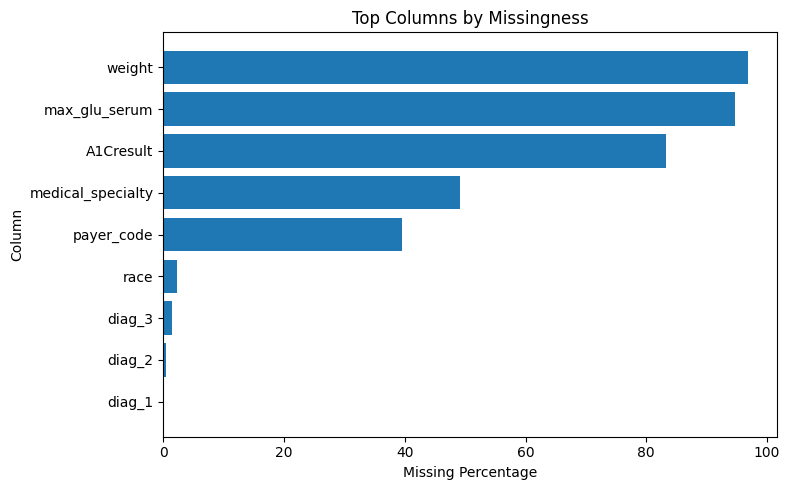

In [8]:
top_missing = missingness[missingness["missing_count"] > 0].head(10)

plt.figure(figsize=(8, 5))
plt.barh(top_missing["column"], top_missing["missing_pct"])
plt.title("Top Columns by Missingness")
plt.xlabel("Missing Percentage")
plt.ylabel("Column")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(FIGURES / "top_missingness_columns.png", dpi=300)
plt.show()

### Interpretation

Missingness is part of the dataset quality story.

High-missingness columns should not be silently dropped during EDA. They should be documented first, then handled later during feature engineering.

A high-missingness column may still be useful as a missingness indicator, but it may not be reliable as a direct predictive feature.

## 6. Helper Functions

In [9]:
def summarize_readmission_by_group(
    data,
    group_col,
    target_col="readmitted_30d",
    group_order=None,
    sort_by="readmission_rate",
    ascending=False
):
    """
    Summarizes observed 30-day readmission rate by a categorical or grouped variable.

    This function is descriptive only. A higher observed readmission rate means the
    group had higher readmission in the dataset, not that the group caused readmission.

    Parameters
    ----------
    data : DataFrame
        Input dataset.
    group_col : str
        Column used for grouping.
    target_col : str
        Binary readmission target.
    group_order : list, optional
        Optional natural order for ordinal groups.
    sort_by : str
        Column used for sorting. Use group_col for ordinal variables.
    ascending : bool
        Sort direction.
    """
    summary = (
        data
        .groupby(group_col, dropna=False, observed=False)
        .agg(
            encounter_count=(target_col, "size"),
            readmission_count=(target_col, "sum"),
            readmission_rate=(target_col, "mean")
        )
        .reset_index()
    )

    summary["readmission_rate"] = summary["readmission_rate"].round(4)

    if group_order is not None:
        summary[group_col] = pd.Categorical(
            summary[group_col],
            categories=group_order,
            ordered=True
        )
        summary = summary.sort_values(group_col)
        summary[group_col] = summary[group_col].astype(str)
    else:
        summary = summary.sort_values(sort_by, ascending=ascending)

    return summary

In [10]:
def plot_readmission_rate_bar(
    summary,
    group_col,
    title,
    xlabel,
    filename,
    baseline_rate=baseline_readmission_rate,
    figsize=(7, 4),
    rotation=0
):
    """
    Plots readmission rate by group and saves the figure.
    """
    plt.figure(figsize=figsize)
    plt.bar(
        summary[group_col].astype(str),
        summary["readmission_rate"]
    )
    plt.axhline(baseline_rate, linestyle="--", linewidth=1)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Readmission Rate")
    plt.xticks(rotation=rotation)
    plt.tight_layout()

    plt.savefig(FIGURES / filename, dpi=300)
    plt.show()

## 7. Demographic EDA

In [11]:
age_order = [
    "[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)",
    "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)"
]

age_summary = summarize_readmission_by_group(
    df,
    "age",
    group_order= age_order
)

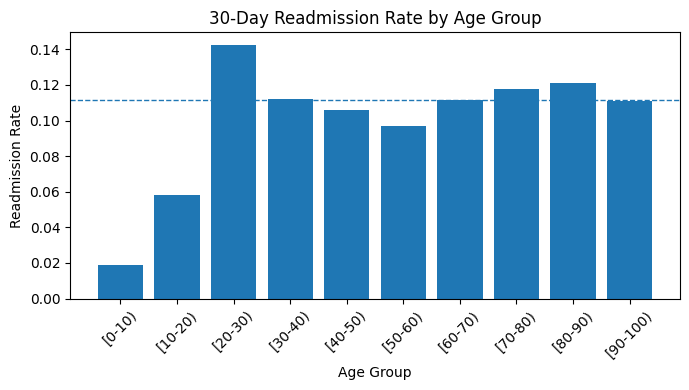

In [12]:
# UCI age groups are stored as ordered interval strings such as [50-60), [60-70), etc.

age_summary_ordered = age_summary.copy()
age_summary_ordered["age"] = pd.Categorical(
    age_summary_ordered["age"],
    categories=age_order,
    ordered=True
)
age_summary_ordered = age_summary_ordered.sort_values("age")

plot_readmission_rate_bar(
    summary=age_summary,
    group_col="age",
    title="30-Day Readmission Rate by Age Group",
    xlabel="Age Group",
    filename="readmission_rate_by_age.png",
    rotation=45
)

In [13]:
race_summary = summarize_readmission_by_group(df, "race")

display(race_summary)

,race,encounter_count,readmission_count,readmission_rate
2,Caucasian,76099,8592,0.1129
0,AfricanAmerican,19210,2155,0.1122
3,Hispanic,2037,212,0.1041
1,Asian,641,65,0.1014
4,Other,1506,145,0.0963
5,NaN,2273,188,0.0827


In [14]:
gender_summary = summarize_readmission_by_group(df, "gender")

display(gender_summary)

,gender,encounter_count,readmission_count,readmission_rate
0,Female,54708,6152,0.1125
1,Male,47055,5205,0.1106
2,Unknown/Invalid,3,0,0.0000


### Interpretation

Race, gender, and age are sensitive demographic fields.

This notebook reviews observed readmission patterns by demographic subgroup, but these fields require careful handling in modeling.

Differences across groups may reflect data quality, historical care patterns, structural inequities, clinical mix, utilization history, or other confounding factors.

Do not interpret these descriptive differences as causal effects.

## 8. Encounter Context EDA

Admission and discharge fields are shown using source-system ID values in this notebook. Human-readable mapping labels should be added in a later interpretation or feature engineering step before final business presentation.

In [15]:
admission_type_summary = summarize_readmission_by_group(df, "admission_type_id")

display(admission_type_summary)

,admission_type_id,encounter_count,readmission_count,readmission_rate
0,1,53990,6221,0.1152
1,2,18480,2066,0.1118
5,6,5291,586,0.1108
2,3,18869,1961,0.1039
4,5,4785,495,0.1034
3,4,10,1,0.1000
7,8,320,27,0.0844
6,7,21,0,0.0000


In [16]:
discharge_summary = summarize_readmission_by_group(df, "discharge_disposition_id")

display(discharge_summary.head(20))

,discharge_disposition_id,encounter_count,readmission_count,readmission_rate
11,12,3,2,0.6667
14,15,63,28,0.4444
8,9,21,9,0.4286
25,28,139,51,0.3669
20,22,1993,552,0.2770
4,5,1184,247,0.2086
1,2,2128,342,0.1607
2,3,13954,2046,0.1466
22,24,48,7,0.1458
6,7,623,90,0.1445


In [17]:
admission_source_summary = summarize_readmission_by_group(df, "admission_source_id")

display(admission_source_summary.head(20))

,admission_source_id,encounter_count,readmission_count,readmission_rate
15,22,12,2,0.1667
2,3,187,29,0.1551
14,20,161,22,0.1366
7,8,16,2,0.1250
4,5,855,101,0.1181
6,7,57494,6720,0.1169
0,1,29565,3130,0.1059
13,17,6781,706,0.1041
8,9,125,13,0.1040
1,2,1104,111,0.1005


### Interpretation

Admission type, discharge disposition, and admission source are operational encounter-level fields.

Because this project uses a near-discharge prediction framing, these fields may be defensible as candidate predictors later.

However, they still require leakage review in Notebook 03 before modeling.

The key question is whether each field would be available at the time the risk score is generated.

## 9. Numeric Feature EDA

In [18]:
numeric_cols = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

numeric_cols = [col for col in numeric_cols if col in df.columns]

numeric_summary = df[numeric_cols].describe().T.reset_index()
numeric_summary = numeric_summary.rename(columns={"index": "column"})

display(numeric_summary)

,column,count,mean,std,min,25%,50%,75%,max
0,time_in_hospital,101766.0,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0
1,num_lab_procedures,101766.0,43.095641,19.674362,1.0,31.0,44.0,57.0,132.0
2,num_procedures,101766.0,1.339730,1.705807,0.0,0.0,1.0,2.0,6.0
3,num_medications,101766.0,16.021844,8.127566,1.0,10.0,15.0,20.0,81.0
4,number_outpatient,101766.0,0.369357,1.267265,0.0,0.0,0.0,0.0,42.0
5,number_emergency,101766.0,0.197836,0.930472,0.0,0.0,0.0,0.0,76.0
6,number_inpatient,101766.0,0.635566,1.262863,0.0,0.0,0.0,1.0,21.0
7,number_diagnoses,101766.0,7.422607,1.933600,1.0,6.0,8.0,9.0,16.0


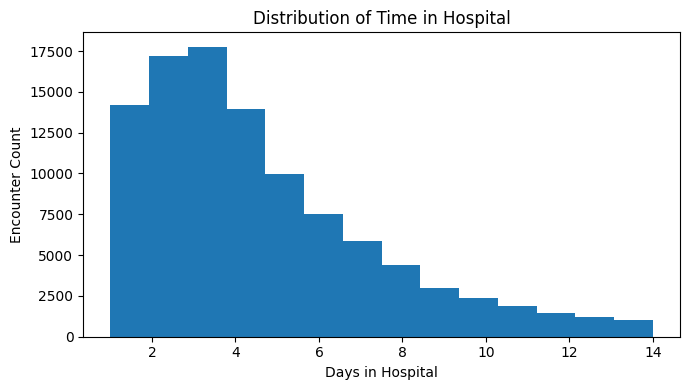

In [19]:
plt.figure(figsize=(7, 4))
plt.hist(df["time_in_hospital"].dropna(), bins=14)
plt.title("Distribution of Time in Hospital")
plt.xlabel("Days in Hospital")
plt.ylabel("Encounter Count")
plt.tight_layout()

plt.savefig(FIGURES / "time_in_hospital_distribution.png", dpi=300)
plt.show()

,time_in_hospital_group,encounter_count,readmission_count,readmission_rate
0,1-2 days,31432,2874,0.0914
1,3-4 days,31680,3538,0.1117
2,5-7 days,23364,2900,0.1241
3,8-14 days,15290,2045,0.1337


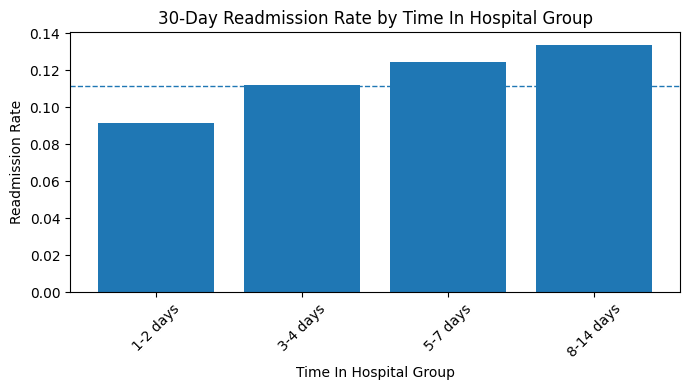

In [20]:
time_hospital_order = ["1-2 days", "3-4 days", "5-7 days", "8-14 days"]

df["time_in_hospital_group"] = pd.cut(
    df["time_in_hospital"],
    bins=[0, 2, 4, 7, 14],
    labels=time_hospital_order,
    include_lowest=True
)

time_hospital_summary = summarize_readmission_by_group(
    df,
    "time_in_hospital_group",
    group_order=time_hospital_order
)

display(time_hospital_summary)

plot_readmission_rate_bar(
    summary=time_hospital_summary,
    group_col="time_in_hospital_group",
    title="30-Day Readmission Rate by Time In Hospital Group",
    xlabel="Time In Hospital Group",
    filename="readmission_rate_by_time_in_hospital.png",
    rotation=45
)

### Interpretation

Time in hospital is an encounter-level feature that may be available near discharge.

Longer hospital stays may be associated with higher clinical complexity, but this EDA does not prove that longer stays cause readmission.

This feature should be reviewed again in Notebook 03 under the near-discharge prediction framing.

## 10. Prior Utilization EDA

In [21]:
prior_util_cols = [
    "number_outpatient",
    "number_emergency",
    "number_inpatient"
]

for col in prior_util_cols:
    if col in df.columns:
        print(f"\n{col}")
        display(df[col].describe())


number_outpatient


count    101766.000000
mean          0.369357
std           1.267265
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          42.000000
Name: number_outpatient, dtype: float64


number_emergency


count    101766.000000
mean          0.197836
std           0.930472
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          76.000000
Name: number_emergency, dtype: float64


number_inpatient


count    101766.000000
mean          0.635566
std           1.262863
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          21.000000
Name: number_inpatient, dtype: float64

In [22]:
# These flags are for EDA only. Formal feature engineering happens in Notebook 03.
df["prior_outpatient_flag"] = np.where(df["number_outpatient"] > 0, 1, 0)
df["prior_emergency_flag"] = np.where(df["number_emergency"] > 0, 1, 0)
df["prior_inpatient_flag"] = np.where(df["number_inpatient"] > 0, 1, 0)

df["total_prior_visits"] = (
    df["number_outpatient"]
    + df["number_emergency"]
    + df["number_inpatient"]
)

In [23]:
prior_flag_cols = [
    "prior_outpatient_flag",
    "prior_emergency_flag",
    "prior_inpatient_flag"
]

for col in prior_flag_cols:
    print(f"\nReadmission by {col}")
    display(summarize_readmission_by_group(df, col))


Readmission by prior_outpatient_flag


,prior_outpatient_flag,encounter_count,readmission_count,readmission_rate
1,1,16739,2281,0.1363
0,0,85027,9076,0.1067



Readmission by prior_emergency_flag


,prior_emergency_flag,encounter_count,readmission_count,readmission_rate
1,1,11383,1890,0.1660
0,0,90383,9467,0.1047



Readmission by prior_inpatient_flag


,prior_inpatient_flag,encounter_count,readmission_count,readmission_rate
1,1,34136,5651,0.1655
0,0,67630,5706,0.0844


In [24]:
prior_visits_order = ["0", "1", "2-3", "4-10", "11+"]


df["total_prior_visits_group"] = pd.cut(
    df["total_prior_visits"],
    bins=[-1, 0, 1, 3, 10, np.inf],
    labels=["0", "1", "2-3", "4-10", "11+"]
)

prior_visits_summary = summarize_readmission_by_group(df, "total_prior_visits_group", group_order=prior_visits_order)

display(prior_visits_summary)

,total_prior_visits_group,encounter_count,readmission_count,readmission_rate
0,0,55828,4564,0.0818
1,1,19941,2306,0.1156
2,2-3,15966,2373,0.1486
3,4-10,9041,1807,0.1999
4,11+,990,307,0.3101


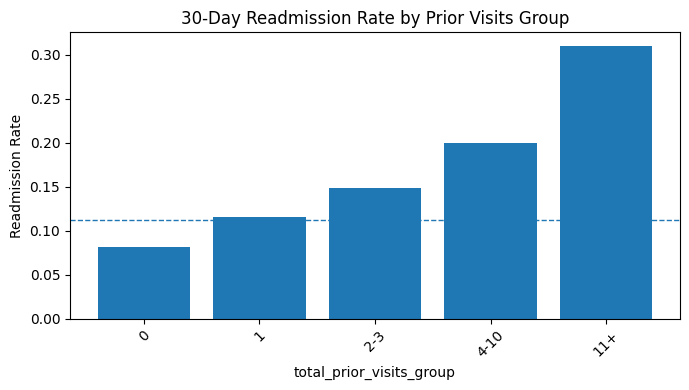

In [25]:
prior_visits_summary_ordered = prior_visits_summary.copy()
prior_visits_summary_ordered["total_prior_visits_group"] = pd.Categorical(
    prior_visits_summary_ordered["total_prior_visits_group"],
    categories=prior_visits_order,
    ordered=True
)
prior_visits_summary_ordered = prior_visits_summary_ordered.sort_values("total_prior_visits_group")

plot_readmission_rate_bar(
    summary=prior_visits_summary,
    group_col="total_prior_visits_group",
    title="30-Day Readmission Rate by Prior Visits Group",
    xlabel="total_prior_visits_group",
    filename="readmission_rate_by_total_prior_visits.png",
    rotation=45
)

### Interpretation

Prior outpatient, emergency, and inpatient utilization are important descriptive indicators.

Higher prior utilization may identify patients with more complex or unstable care patterns.

This should be described as association, not causation.

## 11. Clinical Complexity and Medication EDA

In [26]:
diagnosis_order = ["1-3", "4-6", "7-9", "10+"]


df["diagnosis_count_group"] = pd.cut(
    df["number_diagnoses"],
    bins=[0, 3, 6, 9, np.inf],
    labels=["1-3", "4-6", "7-9", "10+"],
    include_lowest=True
)


diagnosis_summary = summarize_readmission_by_group(df, "diagnosis_count_group", group_order=diagnosis_order)

display(diagnosis_summary)

,diagnosis_count_group,encounter_count,readmission_count,readmission_rate
0,1-3,4077,284,0.0697
1,4-6,27091,2558,0.0944
2,7-9,70483,8498,0.1206
3,10+,115,17,0.1478


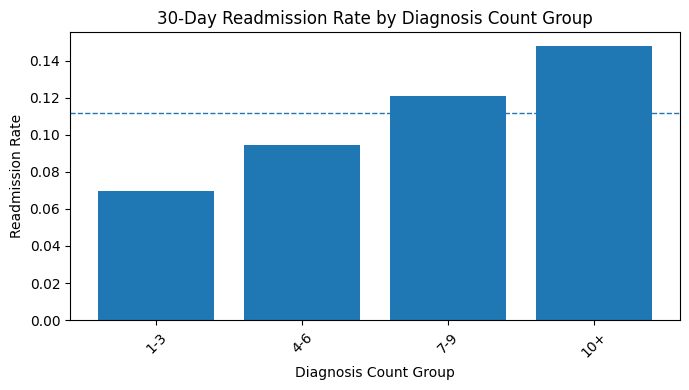

In [27]:
diagnosis_summary_ordered = diagnosis_summary.copy()
diagnosis_summary_ordered["diagnosis_count_group"] = pd.Categorical(
    diagnosis_summary_ordered["diagnosis_count_group"],
    categories=diagnosis_order,
    ordered=True
)
diagnosis_summary_ordered = diagnosis_summary_ordered.sort_values("diagnosis_count_group")

plot_readmission_rate_bar(
    summary=diagnosis_summary,
    group_col="diagnosis_count_group",
    title="30-Day Readmission Rate by Diagnosis Count Group",
    xlabel="Diagnosis Count Group",
    filename="readmission_rate_by_diagnosis_count.png",
    rotation=45
)

,medication_count_group,encounter_count,readmission_count,readmission_rate
0,1-10,25861,2344,0.0906
1,11-20,52025,5962,0.1146
2,21-30,18643,2400,0.1287
3,31+,5237,651,0.1243


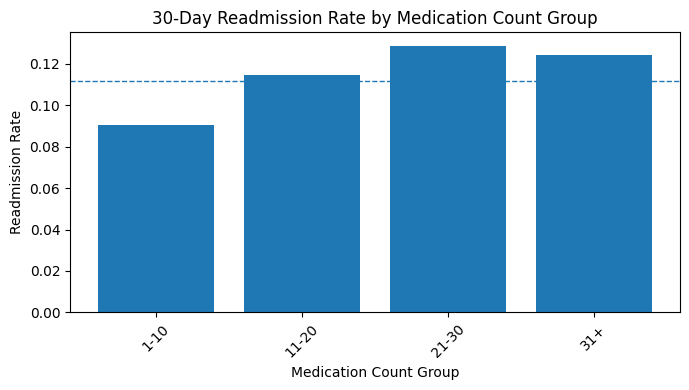

In [28]:
medication_order = ["1-10", "11-20", "21-30", "31+"]

df["medication_count_group"] = pd.cut(
    df["num_medications"],
    bins=[0, 10, 20, 30, np.inf],
    labels=medication_order,
    include_lowest=True
)

medication_summary = summarize_readmission_by_group(
    df,
    "medication_count_group",
    group_order=medication_order
)

display(medication_summary)

plot_readmission_rate_bar(
    summary=medication_summary,
    group_col="medication_count_group",
    title="30-Day Readmission Rate by Medication Count Group",
    xlabel="Medication Count Group",
    filename="readmission_rate_by_medication_count.png",
    rotation=45
)

In [29]:
diabetes_med_cols = [
    "insulin",
    "change",
    "diabetesMed",
    "A1Cresult",
    "max_glu_serum"
]

diabetes_med_cols = [col for col in diabetes_med_cols if col in df.columns]

for col in diabetes_med_cols:
    print(f"\nReadmission by {col}")
    display(summarize_readmission_by_group(df, col))


Readmission by insulin


,insulin,encounter_count,readmission_count,readmission_rate
0,Down,12218,1698,0.1390
3,Up,11316,1470,0.1299
2,Steady,30849,3433,0.1113
1,No,47383,4756,0.1004



Readmission by change


,change,encounter_count,readmission_count,readmission_rate
0,Ch,47011,5558,0.1182
1,No,54755,5799,0.1059



Readmission by diabetesMed


,diabetesMed,encounter_count,readmission_count,readmission_rate
1,Yes,78363,9111,0.1163
0,No,23403,2246,0.0960



Readmission by A1Cresult


,A1Cresult,encounter_count,readmission_count,readmission_rate
3,NaN,84748,9681,0.1142
0,>7,3812,383,0.1005
1,>8,8216,811,0.0987
2,Norm,4990,482,0.0966



Readmission by max_glu_serum


,max_glu_serum,encounter_count,readmission_count,readmission_rate
1,>300,1264,181,0.1432
0,>200,1485,185,0.1246
2,Norm,2597,295,0.1136
3,NaN,96420,10696,0.1109


In [30]:
medication_columns = [
    "metformin", "repaglinide", "nateglinide", "chlorpropamide",
    "glimepiride", "acetohexamide", "glipizide", "glyburide",
    "tolbutamide", "pioglitazone", "rosiglitazone", "acarbose",
    "miglitol", "troglitazone", "tolazamide", "examide",
    "citoglipton", "insulin", "glyburide-metformin",
    "glipizide-metformin", "glimepiride-pioglitazone",
    "metformin-rosiglitazone", "metformin-pioglitazone"
]

medication_columns = [col for col in medication_columns if col in df.columns]

# Values such as Up and Down indicate medication changes during the encounter.
df["medication_change_count"] = df[medication_columns].isin(["Up", "Down"]).sum(axis=1)

display(df["medication_change_count"].describe())

count    101766.000000
mean          0.287444
std           0.487526
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           4.000000
Name: medication_change_count, dtype: float64

In [31]:
med_change_order = ["0", "1", "2", "3+"]

df["medication_change_group"] = pd.cut(
    df["medication_change_count"],
    bins=[-1, 0, 1, 2, np.inf],
    labels=med_change_order
)

med_change_summary = summarize_readmission_by_group(
    df,
    "medication_change_group",
    group_order=med_change_order
)

display(med_change_summary)

,medication_change_group,encounter_count,readmission_count,readmission_rate
0,0,74063,7738,0.1045
1,1,26272,3444,0.1311
2,2,1318,159,0.1206
3,3+,113,16,0.1416


### Interpretation

Diagnosis count, medication count, insulin use, diabetes medication use, and medication changes may reflect clinical complexity.

These patterns are useful for understanding the population and identifying candidate features.

However, they still need leakage and prediction-timing review before being used in a model.

## 12. Export Outputs

In [32]:
eda_key_metrics = pd.DataFrame({
    "metric": [
        "total_encounters",
        "readmitted_30d_count",
        "baseline_readmission_rate",
        "unique_patients",
        "repeated_patient_rows"
    ],
    "value": [
        len(df),
        int(df["readmitted_30d"].sum()),
        round(df["readmitted_30d"].mean(), 4),
        df["patient_nbr"].nunique() if "patient_nbr" in df.columns else np.nan,
        len(df) - df["patient_nbr"].nunique() if "patient_nbr" in df.columns else np.nan
    ]
})

display(eda_key_metrics)

,metric,value
0,total_encounters,101766.0000
1,readmitted_30d_count,11357.0000
2,baseline_readmission_rate,0.1116
3,unique_patients,71518.0000
4,repeated_patient_rows,30248.0000


In [33]:
readmitted_distribution.to_csv(MODEL_RESULTS / "eda_readmitted_distribution.csv", index=False)
missingness.to_csv(MODEL_RESULTS / "eda_missingness_summary.csv", index=False)

age_summary.to_csv(MODEL_RESULTS / "eda_readmission_by_age.csv", index=False)
race_summary.to_csv(MODEL_RESULTS / "eda_readmission_by_race.csv", index=False)
gender_summary.to_csv(MODEL_RESULTS / "eda_readmission_by_gender.csv", index=False)

admission_type_summary.to_csv(MODEL_RESULTS / "eda_readmission_by_admission_type.csv", index=False)
discharge_summary.to_csv(MODEL_RESULTS / "eda_readmission_by_discharge_disposition.csv", index=False)
admission_source_summary.to_csv(MODEL_RESULTS / "eda_readmission_by_admission_source.csv", index=False)

time_hospital_summary.to_csv(MODEL_RESULTS / "eda_readmission_by_time_in_hospital.csv", index=False)
prior_visits_summary.to_csv(MODEL_RESULTS / "eda_readmission_by_total_prior_visits.csv", index=False)
diagnosis_summary.to_csv(MODEL_RESULTS / "eda_readmission_by_diagnosis_count.csv", index=False)
medication_summary.to_csv(MODEL_RESULTS / "eda_readmission_by_medication_count.csv", index=False)
med_change_summary.to_csv(MODEL_RESULTS / "eda_readmission_by_medication_change_count.csv", index=False)

eda_key_metrics.to_csv(MODEL_RESULTS / "eda_key_metrics.csv", index=False)

print("EDA tables exported to:", MODEL_RESULTS.relative_to(PROJECT_ROOT))
print("EDA figures exported to:", FIGURES.relative_to(PROJECT_ROOT))

EDA tables exported to: outputs\model_results
EDA figures exported to: outputs\figures


## Notebook 02 Summary

This notebook completed exploratory data analysis for the cleaned diabetes readmission dataset.

Main findings reviewed:

- Overall 30-day readmission prevalence
- Original readmission category distribution
- Missingness patterns
- Readmission rates by age, race, and gender
- Readmission rates by admission and discharge fields
- Readmission rates by prior utilization
- Readmission rates by time in hospital
- Readmission rates by diagnosis count
- Readmission rates by medication count and diabetes medication fields

Important interpretation rule:

All findings are descriptive. Variables associated with higher readmission rates should not be interpreted as causal drivers.

Next step:

Notebook 03 will convert selected raw variables into model-ready features and explicitly review leakage risk.